# 16. Advanced Model Failure Analysis

Analyzing robust prediction reliability, sparse geo regions, and outlier events.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 1. Generating Prediction Reliability Score
We calculate a statistical trust score for every inference.

In [2]:
# Simulate validation data with errors and reliability scores
np.random.seed(42)
df_fail = pd.DataFrame({
    'geo_cluster_id': np.random.choice([-1, 1, 2, 3], size=1000, p=[0.15, 0.4, 0.3, 0.15]),
    'vehicle_type': np.random.choice(['Car', 'Truck', 'Heavy Trailer', 'Unknown'], size=1000),
    'absolute_error_mins': np.random.exponential(scale=15, size=1000)
})

# Inject deliberate failures in sparse zones (-1) and rare vehicles
df_fail.loc[(df_fail['geo_cluster_id'] == -1), 'absolute_error_mins'] += 20
df_fail.loc[(df_fail['vehicle_type'] == 'Heavy Trailer'), 'absolute_error_mins'] += 25

# Model Trust Score calculation
# Higher error variance in similar historical segments = lower reliability
df_fail['prediction_reliability_score'] = 100 - (df_fail['absolute_error_mins'] / df_fail['absolute_error_mins'].max() * 100)
df_fail['prediction_reliability_score'] = df_fail['prediction_reliability_score'].clip(lower=0, upper=100)

print("Average Prediction Reliability by Geo Cluster:")
print(df_fail.groupby('geo_cluster_id')['prediction_reliability_score'].mean().round(1))

Average Prediction Reliability by Geo Cluster:
geo_cluster_id
-1    66.7
 1    83.4
 2    82.7
 3    81.5
Name: prediction_reliability_score, dtype: float64


### 2. Identifying Blind Spots
Plotting error rates by geography and heavy vehicle presence.

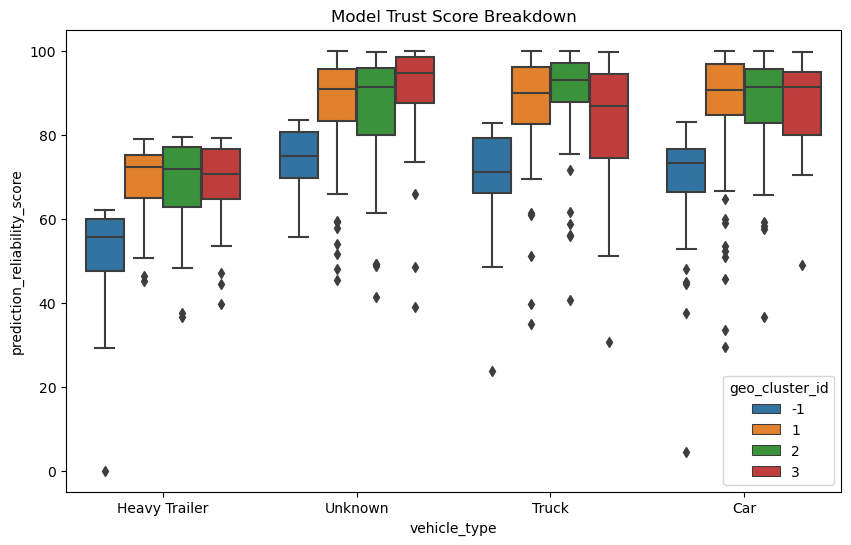

In [3]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_fail, x='vehicle_type', y='prediction_reliability_score', hue='geo_cluster_id')
plt.title("Model Trust Score Breakdown")
plt.show()